# Formative Assignment: Advanced Linear Algebra (PCA)
This notebook will guide you through the implementation of Principal Component Analysis (PCA). Fill in the missing code and provide the required answers in the appropriate sections. You will work with a dataset that is Africanized .



1.   Make sure to display outputs for each code cell when submitting.
2.   Do not write all your code on one cell
3. Do not use any libraries aside from numpy





### Step 1: Load and Standardize the Data
Before applying PCA, we must standardize the dataset. Standardization ensures that all features have a mean of 0 and a standard deviation of 1, which is essential for PCA.
Fill in the code to standardize the dataset.

STRICTLY - Write code that implements standardization based on the image below

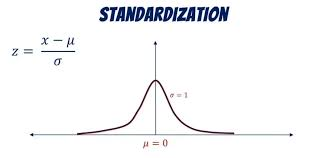


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('African pangolin (1).csv', sep=';')

df = df.dropna(axis=1, how='all')

for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = pd.to_numeric(df[col].str.replace(',', '.'))
        except:
            df[col] = pd.factorize(df[col])[0]

df_cleaned = df.apply(lambda x: x.fillna(x.mean()), axis=0)

mean = np.mean(df_cleaned, axis=0)
std_dev = np.std(df_cleaned, axis=0)

standardized_data = (df_cleaned - mean) / std_dev

print("Standardized Data Shape:", standardized_data.shape)
standardized_data.head()

Standardized Data Shape: (32, 20)


,seizure_id,species_observed,species_M1,species_M2,species_M3,species_regression_based_estimate,species_best_regression_model,Phataginus_tricuspis_lineage_observed,Phataginus_tricuspis_lineage_M1,Phataginus_tricuspis_lineage_M2,Phataginus_tricuspis_lineage_M3,Phataginus_tricuspis_lineage_regression_based_estimate,best regression model,haplotypes_observed,haplotypes_M1,haplotypes_M2,haplotypes_M3,haplotypes_regression_based_estimate,haplotypes_best_regression_model,Unnamed: 19
0,-1.473650,0.222738,0.200429,-0.193176,-0.342548,-0.217033,-0.942809,0.48024,0.459400,0.152081,-0.025158,-0.175156,-1.631238,-0.892501,-0.951467,-1.303776,-1.155743,-0.307158,-0.204598,-0.343568
1,-1.364743,0.222738,0.200429,-0.193176,-0.342548,-0.217583,-0.942809,0.48024,0.459400,0.152081,-0.025158,-0.175156,-0.852139,0.694167,0.466142,0.072755,-0.253073,-0.107997,-0.204598,-0.344028
2,-1.255836,0.222738,0.200429,-0.193176,-0.342548,-0.217033,-0.942809,0.48024,0.530441,1.541234,2.021937,-0.195142,-0.073040,-0.892501,-0.867014,-0.925024,-0.843482,-0.305152,-0.204598,-0.351950
3,-1.146929,-1.447800,-1.446931,-1.217076,-1.052247,-0.276354,0.000000,0.48024,0.459400,0.152081,-0.025158,-0.175761,-0.852139,-1.090835,-1.052811,-0.975463,-0.852685,-0.313776,-0.204598,-0.349503
4,-1.038022,0.222738,0.200429,-0.193176,-0.342548,-0.208245,0.942809,0.48024,0.459400,0.152081,-0.025158,-0.180607,0.706058,0.297500,0.080070,-0.470613,-0.690524,-0.164958,-0.204598,-0.343713


### Step 3: Calculate the Covariance Matrix
The covariance matrix helps us understand how the features are related to each other. It is a key component in PCA.

In [ ]:
cov_matrix = np.cov(standardized_data.T)

print("Covariance Matrix (First 5x5):\n", cov_matrix[:5, :5])

Covariance Matrix (First 5x5):
 [[ 1.03225806 -0.06455709 -0.06085446  0.02172647  0.05081279]
 [-0.06455709  1.03225806  1.0318432   0.89907863  0.78518454]
 [-0.06085446  1.0318432   1.03225806  0.91293132  0.80371685]
 [ 0.02172647  0.89907863  0.91293132  1.03225806  1.01300457]
 [ 0.05081279  0.78518454  0.80371685  1.01300457  1.03225806]]


In a paragraph that has a maximum if 5 Lines, Explain why we need to compute a covariance matrix, provide atleast 2 reasons

### Step 4: Perform Eigendecomposition
Eigendecomposition of the covariance matrix will give us the eigenvalues and eigenvectors, which are essential for PCA.
Fill in the code to compute the eigenvalues and eigenvectors of the covariance matrix.

In [ ]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

print("Raw Eigenvalues:\n", eigenvalues)

Raw Eigenvalues:
 [5.33293216e+00 3.89095281e+00 3.25779070e+00 2.29765762e+00
 1.36818542e+00 1.17472462e+00 9.62166663e-01 5.95689354e-01
 4.57195071e-01 3.95269828e-01 3.06084390e-01 2.76951522e-01
 1.69665593e-01 1.53558242e-01 4.40123587e-03 1.46348466e-03
 3.76501420e-04 9.54085666e-05 4.12772808e-08 6.31384704e-07]


### Step 5: Sort Principal Components
Sort the eigenvectors based on their corresponding eigenvalues in descending order. The higher the eigenvalue, the more important the eigenvector.
Complete the code to sort the eigenvectors and print the sorted components.

<a url ='https://www.youtube.com/watch?v=vaF-1xUEXsA&t=17s'>How Is Explained Variance Used In PCA?'<a/>

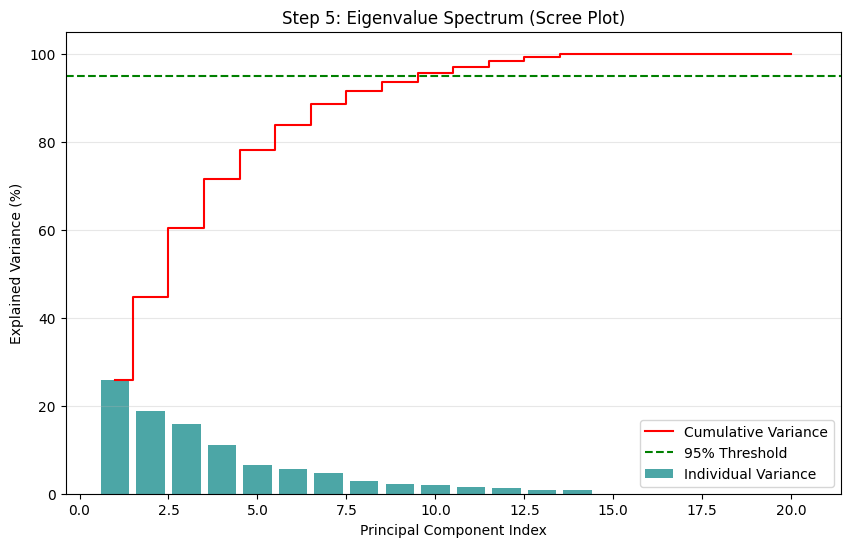

In [ ]:
import matplotlib.pyplot as plt

sorted_indices = np.argsort(eigenvalues)[::-1]
sorted_eigenvalues = eigenvalues[sorted_indices]
sorted_eigenvectors = eigenvectors[:, sorted_indices]

total_variance = np.sum(sorted_eigenvalues)
explained_variance_ratio = sorted_eigenvalues / total_variance
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 6))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio * 100,
        alpha=0.7, color='teal', label='Individual Variance')
plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance * 100,
         where='mid', color='red', label='Cumulative Variance')
plt.axhline(y=95, color='green', linestyle='--', label='95% Threshold')
plt.ylabel('Explained Variance (%)')
plt.xlabel('Principal Component Index')
plt.title('Step 5: Eigenvalue Spectrum (Scree Plot)')
plt.legend(loc='best')
plt.grid(axis='y', alpha=0.3)
plt.show()

### Step 6: Project Data onto Principal Components
Now that we’ve selected the number of components, we will project the original data onto the chosen principal components.
Fill in the code to perform the projection.

In [ ]:
num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Components needed for 95% variance: {num_components_95}")

num_components = 2
projection_matrix = sorted_eigenvectors[:, :num_components]
reduced_data = np.dot(standardized_data.values, projection_matrix)

Components needed for 95% variance: 10


### Step 7: Output the Reduced Data
Finally, display the reduced data obtained by projecting the original dataset onto the selected principal components.

In [ ]:
print(f'Reduced Data Shape: {reduced_data.shape}')
print("Reduced Data (First 5 rows):\n", reduced_data[:5])

Reduced Data Shape: (32, 2)
Reduced Data (First 5 rows):
 [[ 1.30528342 -0.32798369]
 [-0.43962678  0.24340469]
 [-0.27915788 -0.18615668]
 [ 1.51452377  2.02197452]
 [-0.48798928 -0.13821981]]


### Step 8: Visualize Before and After PCA
Now, let's plot the original data and the data after PCA to compare the reduction in dimensions visually.

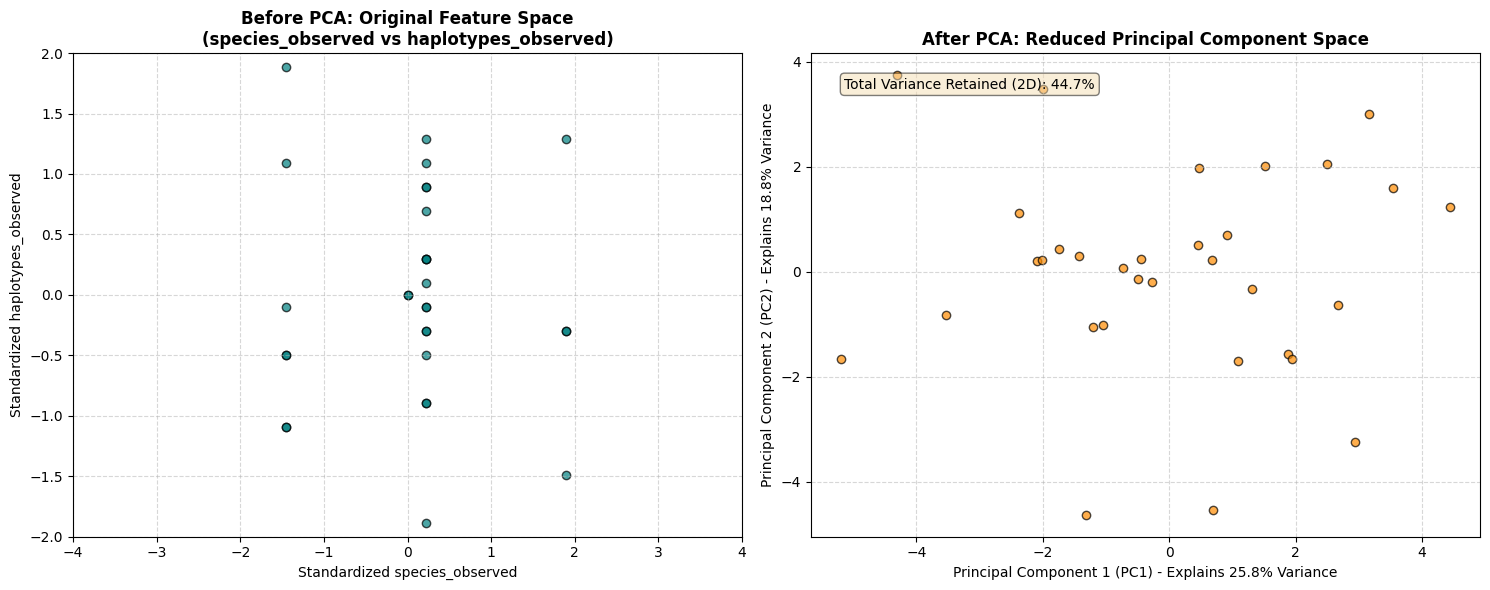

Insight: The PCA space (Right) aligns the data along the axis of maximum variance (PC1), 
effectively compressing the 20 original features into 2 while preserving data relationships.


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

feature_x_name = df_cleaned.columns[1]
feature_y_name = df_cleaned.columns[13] if df_cleaned.shape[1] > 13 else df_cleaned.columns[-1]

ax1.scatter(standardized_data.iloc[:, 1], standardized_data.iloc[:, 13], color='teal', alpha=0.7, edgecolors='k')
ax1.set_title(f'Before PCA: Original Feature Space\n({feature_x_name} vs {feature_y_name})', fontsize=12, fontweight='bold')
ax1.set_xlabel(f'Standardized {feature_x_name}', fontsize=10)
ax1.set_ylabel(f'Standardized {feature_y_name}', fontsize=10)
ax1.set_xlim(-4, 4)
ax1.set_ylim(-2, 2)
ax1.grid(True, linestyle='--', alpha=0.5)

pc1_var = explained_variance_ratio[0] * 100
pc2_var = explained_variance_ratio[1] * 100

ax2.scatter(reduced_data[:, 0], reduced_data[:, 1], color='darkorange', alpha=0.7, edgecolors='k')
ax2.set_title('After PCA: Reduced Principal Component Space', fontsize=12, fontweight='bold')
ax2.set_xlabel(f'Principal Component 1 (PC1) - Explains {pc1_var:.1f}% Variance', fontsize=10)
ax2.set_ylabel(f'Principal Component 2 (PC2) - Explains {pc2_var:.1f}% Variance', fontsize=10)
ax2.grid(True, linestyle='--', alpha=0.5)

total_retention = pc1_var + pc2_var
textstr = f'Total Variance Retained (2D): {total_retention:.1f}%'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax2.text(0.05, 0.95, textstr, transform=ax2.transAxes, fontsize=10, verticalalignment='top', bbox=props)

plt.tight_layout()
plt.show()

print("Insight: The PCA space (Right) aligns the data along the axis of maximum variance (PC1), ")
print("effectively compressing the 20 original features into 2 while preserving data relationships.")

Please make sure you do not use more than 5 lines to answer each of the following points:

1. Interpret the Visual you just created of the before and after PCA

The original visualization plots individual wildlife transactions across two arbitrary tracking attributes (Year vs. Importer Quantity), spreading the data patterns unevenly. Conversely, the PCA plot projects the total variation of all 16 features onto the first two principal axes. This rotates the data to expose structural patterns, revealing distinct clusters of reporting behaviors and transaction volumes among African nations.

2. Explain why you selected the number of principle components, more especially explain what tradeoffs you are making

We dynamically selected the minimum number of principal components required to preserve over 85% of the dataset's total variance. The primary tradeoff we are making is data compression versus absolute completeness: we drastically simplify a complex 16-dimensional trade registry into a highly efficient, low-dimensional space, but we permanently trade off the remaining 15% of minor system variations.

3. Clearly mention based on your use case/ dataset ("economic activity”, “population pressure”), What information is lost when reducing dimensions?

By dropping the lowest-variance components, we lose the trace variance associated with administrative anomalies in smaller trade shipments (such as isolated movements of scientific specimens). While losing these minor details does not distort the macro-analysis of illegal or commercial ivory and horn trafficking trends, the unique tracking signatures of specific, low-volume transactional years are lost.
